In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [2]:
df = pd.read_csv(
    "reddit_preprocessed.csv"
)

df.head()

,Unnamed: 0,clean_comment,category,word_count
0,0,family mormon never tried explain still stare ...,1,26
1,1,buddhism much lot compatible christianity espe...,1,140
2,2,seriously say thing first get complex explain ...,-1,46
3,3,learned want teach different focus goal not wr...,0,15
4,4,benefit may want read living buddha living chr...,1,68


In [3]:
df.drop(
    columns=["Unnamed: 0"],
    inplace=True
)

In [4]:
X=  df["clean_comment"]
y= df ['category']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
def run_ngram_experiment(ngram_range):
  tfidf = TfidfVectorizer(
      ngram_range= ngram_range,
      max_features = 5000
  )

  X_train_vec = tfidf.fit_transform(X_train)

  X_test_vec = tfidf.transform(X_test)

  model = RandomForestClassifier(
      n_estimators = 200,
      max_depth=15,
      random_state=42


  )

  model.fit(
      X_train_vec,y_train
  )

  y_pred = model.predict(
      X_test_vec

  )

  accuracy = accuracy_score(
      y_test, y_pred
  )
  return accuracy

In [9]:
unigram_acc = run_ngram_experiment((1,1))
print("Unigram Accuracy:",unigram_acc)

Unigram Accuracy: 0.65279284164859


In [10]:
bigram_acc = run_ngram_experiment(
    (1,2)
)

print(
    "Bigram Accuracy:",
    bigram_acc
)

Bigram Accuracy: 0.6508947939262473


In [11]:
trigram_acc = run_ngram_experiment(
    (1,3)
)

print(
    "Trigram Accuracy:",
    trigram_acc
)

Trigram Accuracy: 0.6468275488069414


In [12]:
results = pd.DataFrame({

    "Ngram":[
        "Unigram",
        "Bigram",
        "Trigram"
    ],

    "Accuracy":[
        unigram_acc,
        bigram_acc,
        trigram_acc
    ]

})

results

,Ngram,Accuracy
0,Unigram,0.652793
1,Bigram,0.650895
2,Trigram,0.646828


In [14]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Ngram,Accuracy
0,Unigram,0.652793
1,Bigram,0.650895
2,Trigram,0.646828


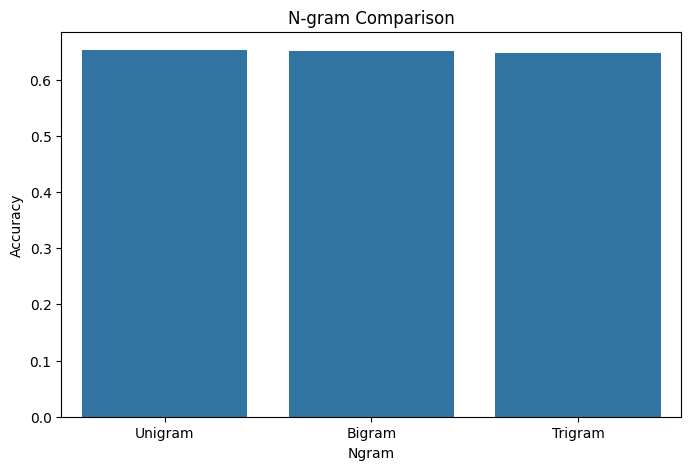

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data= results,
    x="Ngram",
    y="Accuracy"
)

plt.title("N-gram Comparison")
plt.show()

In [18]:
results.to_csv(
    "ngram_results.csv",
    index=False
)